#**PLN - Universidad Nacional de Colombia**

## Taller 2

### Representaciones: bow, tfidf, word2vect

### Profesora Elizabeth León Guzmán

### Estudiantes: Francisco José Salamanca Rivera, Jorge Morales, Omar Orlando Riaño

---

### 1. tfidf

* Escoger y bajar el conjunto de documentos en español

* Cargarlo el data set

* Construir la matriz tf, tf_idf, y trigramas por palabras

* Seleccionar cinco documentos y clasificarlos con los 5 vecinos más cercanos usando tf_idf con similitud coseno

In [ ]:
#%pip install nltk emoji
#%pip install gensim

In [1]:
import pandas as pd
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import numpy as np
import re
import string
import nltk
from nltk.stem.snowball import SnowballStemmer
import emoji

In [2]:
df = pd.read_csv(
    "reviews_filmaffinity.csv",
    sep=r"\|\|",          # separador literal ||
    engine="python",      # necesario para regex
    encoding="utf-8"      # ajusta si ves caracteres raros
)

df.head()


,film_name,gender,film_avg_rate,review_rate,review_title,review_text
0,Ocho apellidos vascos,Comedia,"6,0",3.0,OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO,La mayor virtud de esta película es su existen...
1,Ocho apellidos vascos,Comedia,"6,0",2.0,El perro verde,"No soy un experto cinéfilo, pero pocas veces m..."
2,Ocho apellidos vascos,Comedia,"6,0",2.0,Si no eres de comer mierda... no te comas esta...,Si no eres un incondicional del humor estilo T...
3,Ocho apellidos vascos,Comedia,"6,0",2.0,Aida: The movie,"No sé qué está pasando, si la gente se deja ll..."
4,Ocho apellidos vascos,Comedia,"6,0",2.0,UN HOMBRE SOLO (Julio Iglesias 1987),"""Pero cuando amanece,y me quedo solo,siento en..."


In [3]:
# Seleccionar solo la columna de texto
textos = df['review_text'].astype(str)

In [4]:
# Funcion de Limpieza


# Descargar palabras de NLTK predefinidas
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True) # Lematizacion

# Stemmer en español
stemmer = SnowballStemmer('spanish')

def clean_text(text):
    # 1. Quitar links
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 2. Quitar Emojis
    text = emoji.demojize(text) # Convert emojis to text descriptions
    text = re.sub(r':\S+:', '', text) # Remove the text descriptions

    # 3. Quitar puntuaciones
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 4. Quitar numeros
    text = re.sub(r'\d+', '', text)

    # 5. Minusculizar
    text = text.lower()

    # 6. Controlar los caracteres repetidos
    text = re.sub(r'(.)\1+', r'\1\1', text)

    # 7. Quitar las palabras STOP en español
    spanish_stop_words = set(nltk.corpus.stopwords.words('spanish'))
    text = ' '.join([word for word in text.split() if word not in spanish_stop_words])

    # 8. aplicar el stemming
    text = ' '.join([stemmer.stem(word) for word in text.split()])

    return text

In [5]:
# Comparar los documentos luego de la transformacion
df['cleaned_review_text'] = df['review_text'].apply(clean_text)
display(df[['review_text', 'cleaned_review_text']].head())


,review_text,cleaned_review_text
0,La mayor virtud de esta película es su existen...,mayor virtud pelicul existenciael hech pod jug...
1,"No soy un experto cinéfilo, pero pocas veces m...",expert cinefil poc vec tan jueg sal cin autent...
2,Si no eres un incondicional del humor estilo T...,si incondicional humor estil tel si termin cap...
3,"No sé qué está pasando, si la gente se deja ll...",se pas si gent dej llev mod si verd gust sol v...
4,"""Pero cuando amanece,y me quedo solo,siento en...",amanecey qued solosient fondoun mar vacioun se...


In [ ]:
# Crear matriz TF, frecuencias absolutas
#utilizando el conjunto ya limpio utilizando la funcion dada por sckit-learn


tf_vectorizer_cleaned = CountVectorizer()
X_tf_cleaned = tf_vectorizer_cleaned.fit_transform(df['cleaned_review_text'])

#observar
# Primeras 5 filas y primeras 15 columnas como ejemplo
sample_tf = pd.DataFrame(
    X_tf_cleaned[:5, 10:20].toarray(),
    columns=tf_vectorizer_cleaned.get_feature_names_out()[10:20]
)
sample_tf

,abaj,abajo,abajocom,abajoel,abajol,abajoper,abal,abalanz,aban,abander
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Crear la matriz RF-IDF,
#utilizando el conjunto ya limpio utilizando la funcion dada por sckit-learn

#TF: frecuencia relativa de la palabra en ese documento.
#IDF: “rareza” en todo el corpus.

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_review_text'])

#observar
# Primeras 5 filas y primeras 15 columnas como ejemplo
sample_tf = pd.DataFrame(
    X_tfidf[:5, 10:20].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()[10:20]
)
sample_tf


,abaj,abajo,abajocom,abajoel,abajol,abajoper,abal,abalanz,aban,abander
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Crear trigramas por palabras
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))
X_trigram = trigram_vectorizer.fit_transform(df['cleaned_review_text'])

#Dimensiones
print("\nDimensiones de los trigramas:")
print(X_trigram.shape)

# Ver una meuestra
sample_trigrams = pd.DataFrame(
    X_trigram[:5, :10].toarray(),
    columns=trigram_vectorizer.get_feature_names_out()[:10]
)

display(sample_trigrams)


Dimensiones de los trigramas:
(8603, 846022)


,aadam elliot etc,aah noo clar,aah val no,aardm dreamworks aquell,aardm funcion part,aaron abrams destac,aaron abrams emple,aaron ashmor dal,aaron ashmor devon,aaron ashmor record
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Seleccionar los primeros 5 documentos
selected_documents_indices = range(5)
selected_documents_tfidf = X_tfidf[selected_documents_indices]


#  Inicializar el NN con similaridad coseno
nn = NearestNeighbors(n_neighbors=5, algorithm='brute', metric='cosine')

# Ajustar el modelo con la matriz TF-IDF creada
nn.fit(X_tfidf)

# Encontrar los 5 vecinos mas cercanos para cada uno de los 5 docs
distances, indices = nn.kneighbors(selected_documents_tfidf)

# Ver las distancias para cada documento
print("NN para los primeros 5 docs:")
for i, doc_index in enumerate(selected_documents_indices):
    print(f"\nDocument {doc_index}:")
    for j in range(5):
        neighbor_index = indices[i, j]
        distance = distances[i, j]
        print(f"  Neighbor {j+1}: Index {neighbor_index}, Distance {distance:.4f}")

NN para los primeros 5 docs:

Document 0:
  Neighbor 1: Index 0, Distance 0.0000
  Neighbor 2: Index 208, Distance 0.7573
  Neighbor 3: Index 362, Distance 0.7689
  Neighbor 4: Index 310, Distance 0.7740
  Neighbor 5: Index 319, Distance 0.7771

Document 1:
  Neighbor 1: Index 1, Distance 0.0000
  Neighbor 2: Index 1322, Distance 0.8658
  Neighbor 3: Index 4763, Distance 0.8775
  Neighbor 4: Index 5936, Distance 0.8836
  Neighbor 5: Index 137, Distance 0.8837

Document 2:
  Neighbor 1: Index 2, Distance 0.0000
  Neighbor 2: Index 7047, Distance 0.8654
  Neighbor 3: Index 72, Distance 0.8992
  Neighbor 4: Index 5168, Distance 0.9017
  Neighbor 5: Index 7346, Distance 0.9078

Document 3:
  Neighbor 1: Index 3, Distance 0.0000
  Neighbor 2: Index 310, Distance 0.6460
  Neighbor 3: Index 59, Distance 0.6604
  Neighbor 4: Index 146, Distance 0.6752
  Neighbor 5: Index 58, Distance 0.6815

Document 4:
  Neighbor 1: Index 4, Distance 0.0000
  Neighbor 2: Index 1884, Distance 0.8615
  Neighbor

In [ ]:
# llamamr al indice
neighbor_indices_doc0 = indices[0]

# mostrar el doc original del index 0 y ver sus opciones mas parecidad
print("Documento Original 0:")
display(df.loc[selected_documents_indices[0], 'review_text'])

print("\nNN para el documento 0:")
for j, neighbor_index in enumerate(neighbor_indices_doc0):
    print(f"\nNeighbor {j+1} (Index: {neighbor_index}, Distance: {distances[0, j]:.4f}):")
    display(df.loc[neighbor_index, 'review_text'])

Documento Original 0:


'La mayor virtud de esta película es su existencia.El hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y la vasca) sin que nadie se escandalice ni ponga el grito en el cielo, indica mucho de nuestra madurez como nación (pese a quien pese). Bueno, corrijo: el hecho de que podamos jugar y hacer mofa y befa de los tópicos sobre los vascos y el nacionalismo vasco, sin que nadie se escandalice ni ponga el grito en el cielo, indica mucho del grado de normalización de ciertas cuestiones que antes eran llagas abiertas siempre dispuestas a sangrar. Y hago esta corrección, porque los andaluces han sido motivo de guasa siempre y nunca ha pasado nada.Por esto mismo, el planteamiento de "Ocho Apellidos Vascos" es valiente, es oportuno y es oportunista. Seguramente sea esa una de las principales razones por la que los españoles hemos acudido en masa, en una masa casi sin precedentes, a los cines a ver este producto patrocinado por Tele 5. Esa junto con 


NN para el documento 0:

Neighbor 1 (Index: 0, Distance: 0.0000):


'La mayor virtud de esta película es su existencia.El hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y la vasca) sin que nadie se escandalice ni ponga el grito en el cielo, indica mucho de nuestra madurez como nación (pese a quien pese). Bueno, corrijo: el hecho de que podamos jugar y hacer mofa y befa de los tópicos sobre los vascos y el nacionalismo vasco, sin que nadie se escandalice ni ponga el grito en el cielo, indica mucho del grado de normalización de ciertas cuestiones que antes eran llagas abiertas siempre dispuestas a sangrar. Y hago esta corrección, porque los andaluces han sido motivo de guasa siempre y nunca ha pasado nada.Por esto mismo, el planteamiento de "Ocho Apellidos Vascos" es valiente, es oportuno y es oportunista. Seguramente sea esa una de las principales razones por la que los españoles hemos acudido en masa, en una masa casi sin precedentes, a los cines a ver este producto patrocinado por Tele 5. Esa junto con 


Neighbor 2 (Index: 208, Distance: 0.7573):


...

'Reconozco que no tenía demasiadas ganas de ver esta película, pues el cine español (y más aún el cómico) suele provocarme jaquecas y resoplidos hastiados por lo manido y repetitivo que es. Sin duda los defensores a ultranza del cine español se me echarán encima ante tal afirmación, y probablemente uno de los argumentos que enarbolarán para defender su hipótesis será la película "Ocho Apellidos Vascos", que ha arrasado en taquilla y es candidata a convertirse en la comedia del año.¿La película está bien? Pues sí, no lo voy a negar.¿Merece ser la comedia del año? Ni de broma.Me senté a ver esta película sin hacerme demasiadas expectativas, aunque sabía que mucha gente se había partido de risa al verla. Bien, yo no me he partido de risa. Admito que tiene partes muy buenas, y se me ha escapado alguna carcajada con las paridas de Dani Rovira, pero en general me he sentido decepcionada. No me ha parecido la comedia desternillante que esperaba encontrar.En "Ocho Apellidos Vascos", el pilar d


Neighbor 4 (Index: 310, Distance: 0.7740):


'Rafa es un joven señorito andaluz que no ha tenido que salir jamás de su Sevilla natal para conseguir lo único que le importa en la vida: el fino, la gomina, el Betis y las mujeres. Todo cambia cuando conoce una mujer que se resiste a sus encantos: es Amaia, una chica vasca. Decidido a conquistarla, se traslada a un pueblo de las Vascongadas, donde se hace pasar por vasco para vencer su resistencia. Adopta el nombre de Antxon y varios apellidos vascos: Arguiñano, Igartiburu, Erentxun, Gabilondo, Urdangarín, Otegi, Zubizarreta e incluso Clemente.Gran éxito en las taquillas españolas: "Ocho Apellidos Vascos" ha demostrado una solidez inusitada en los cines, pero, ¿es esa solidez taquillera un atributo que se deba a su estupendo resultado final en términos narrativos y artísticos?Lo cierto es que no. La cinta que hoy nos ocupa es una más dentro de ese inmenso mar de cine español de comedia, que en ocasiones es muy positivo, pero que también, en otros momentos, nos da películas realmente 


Neighbor 5 (Index: 319, Distance: 0.7771):


'Poco se puede decir a estas alturas de \'Ocho apellidos vascos\' que no se haya dicho ya. Ha sido un fenómeno de masas sin precedentes que ha arrastrado a la gente a las salas de cine hasta convertirla en la película española más taquillera de la historia (y en la segunda más taquillera en total, únicamente superada por \'Avatar\'). Parecía que la millonada recaudada por \'Lo imposible\', una superproducción con un director consolidado y un reparto internacional, iba a ser insuperable a corto plazo, pero apenas dos años más tarde ha sido una comedia modesta y de pequeño presupuesto la que la ha destronado, rompiendo todos los récords a su paso. En los últimos meses, han sido muchos quienes han tratado de buscar una explicación a semejante éxito: la necesidad de reír en tiempos de crisis, el boca a boca, los tópicos que tanto gustan a los españoles, su potentísima campaña publicitaria, etc. Seguramente todos estos factores habrán influido en mayor o menor medida, pero al final de la cr

### 2. Word2vect

* Usando el mismo conjunto de datos en español
* Construir los vectores de palabras usando word2vect
* Visualizar usando TSNE
* Realizar consultas de palabras para ver el efectos de la similitud
* Guardar el modelo y volverlo a cargar
* Cargar un modelo preentrenado en español y usarlo para mejorar los *embeddings* del conjunto de datos seleccionado
* Realizar las mismas consultas de palabras para ver el efectos de la similitud con este nuevo modelo de embeddings y comparar con las consultas del modelo anterior.

In [ ]:
# Usar el Mismo dataset


#df['cleaned_review_text'] = df['review_text'].apply(clean_text)
#display(df[['review_text', 'cleaned_review_text']].head())

,review_text,cleaned_review_text
0,La mayor virtud de esta película es su existen...,mayor virtud pelicul existenciael hech pod jug...
1,"No soy un experto cinéfilo, pero pocas veces m...",expert cinefil poc vec tan jueg sal cin autent...
2,Si no eres un incondicional del humor estilo T...,si incondicional humor estil tel si termin cap...
3,"No sé qué está pasando, si la gente se deja ll...",se pas si gent dej llev mod si verd gust sol v...
4,"""Pero cuando amanece,y me quedo solo,siento en...",amanecey qued solosient fondoun mar vacioun se...


In [8]:
# Importar el modelo Word2vec

import pandas as pd
import re
import string
import nltk
from nltk.stem.snowball import SnowballStemmer
import emoji
from gensim.models import Word2Vec

# Definir los parametros del modelo
vector_size = 100
window = 5
min_count = 5
epochs = 10

# Inicializar el modelo
w2v_model = Word2Vec(
    vector_size=vector_size,
    window=window,
    min_count=min_count,
    epochs=epochs
)

# Tokenizar el texto limpio a listas de palabras
tokenized_reviews = df['cleaned_review_text'].apply(lambda x: x.split())

# Crear el vocabulario de los datos tokenizados
w2v_model.build_vocab(tokenized_reviews)

# Entrenar el modelo entero
w2v_model.train(
    tokenized_reviews,
    total_examples=w2v_model.corpus_count,
    epochs=epochs
)

print("Total de palabras entrenadas:", w2v_model.corpus_total_words)

Total number of words trained: 909314


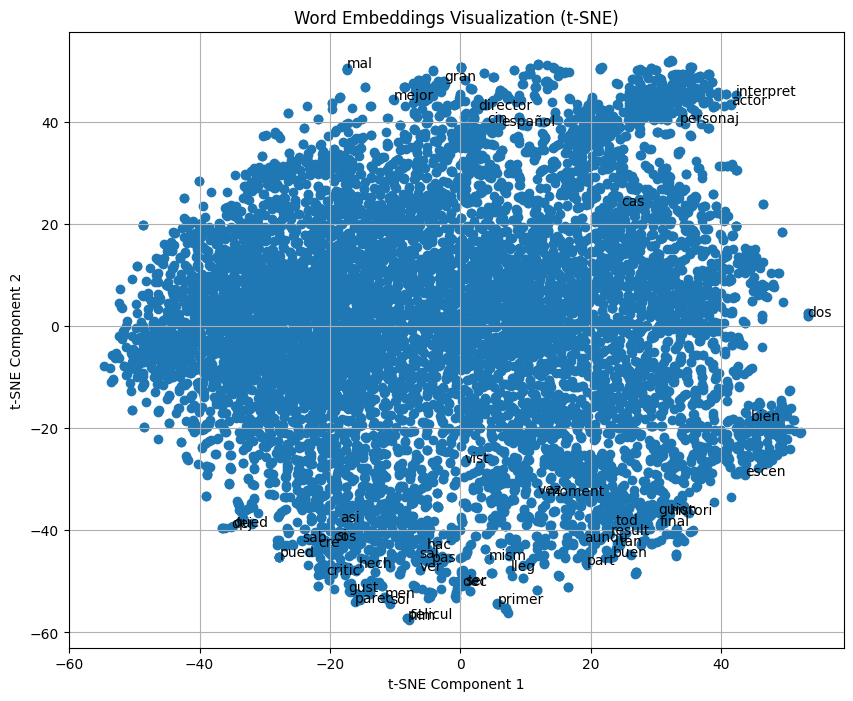

In [9]:

# visualizar con TSNE


from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Extraer los vectores de palabras y vectores
words = list(w2v_model.wv.index_to_key)
vectors = w2v_model.wv[words]

# Aplicar t-sne
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
vectors_tsne = tsne.fit_transform(vectors)

# Crear un df para plotear
tsne_df = pd.DataFrame(data = vectors_tsne, columns = ['tsne_component_1', 'tsne_component_2'])
tsne_df['word'] = words

# Crear el scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(tsne_df['tsne_component_1'], tsne_df['tsne_component_2'])

# Anotar las primeras 50 palabras
for i in range(50):
    plt.annotate(tsne_df['word'][i], (tsne_df['tsne_component_1'][i], tsne_df['tsne_component_2'][i]))

plt.title('Embedding de las palabras')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

In [11]:
#Encontrar similitudes

# Seleccionar algunas palabras de ejemplo:
query_words = ['pelicul', 'buen', 'cin', 'gent', 'histori']

# Encontrar las 5 palabras mas parecidas
n_neighbors = 5

print("Palabras similares con el modelo entrenado")
for word in query_words:
    if word in w2v_model.wv:
        similar_words = w2v_model.wv.most_similar(word, topn=n_neighbors)
        print(f"\nPalabras mas similares a: '{word}':")
        for similar_word, similarity_score in similar_words:
            print(f"  - {similar_word}: {similarity_score:.4f}")
    else:
        print(f"\nla palabra '{word}' no se encontro en el vocabulario.")

Palabras similares con el modelo entrenado

Palabras mas similares a: 'pelicul':
  - peli: 0.7360
  - cint: 0.7130
  - film: 0.6411
  - films: 0.4774
  - cin: 0.4730

Palabras mas similares a: 'buen':
  - buenisim: 0.6502
  - excelent: 0.6165
  - decent: 0.6095
  - regul: 0.5684
  - floj: 0.5234

Palabras mas similares a: 'cin':
  - superproduccion: 0.6777
  - industri: 0.5731
  - produccion: 0.5482
  - anim: 0.5386
  - cinefil: 0.5385

Palabras mas similares a: 'gent':
  - porqu: 0.6161
  - person: 0.6141
  - enfad: 0.5754
  - mierd: 0.5731
  - indign: 0.5561

Palabras mas similares a: 'histori':
  - tram: 0.5925
  - argument: 0.5378
  - acontec: 0.5176
  - narracion: 0.4865
  - histor: 0.4788


In [12]:
#Guardar el modelo en disco


# Nombre
model_filename = 'word2vec_model.wv'

# Guardar el modelo
w2v_model.wv.save(model_filename)

# Cargar los vectores del modelo guardado
from gensim.models import KeyedVectors
loaded_w2v_vectors = KeyedVectors.load(model_filename)

# Vefificar que cargo
print(f"\nVerificacion encontrando los parecidos a 'pelicul':")
try:
    similar_words_loaded = loaded_w2v_vectors.most_similar('pelicul', topn=5)
    for similar_word, similarity_score in similar_words_loaded:
        print(f"  - {similar_word}: {similarity_score:.4f}")
except KeyError:
    print(f"\nla palabra 'pelicul' no se encontro en el vocabulario.")


Verificacion encontrando los parecidos a 'pelicul':
  - peli: 0.7360
  - cint: 0.7130
  - film: 0.6411
  - films: 0.4774
  - cin: 0.4730


In [22]:
#Cargar el modelo preentrenado

import gensim.downloader as api

# Descargar el modelo preentreno
try:
    print("Modelos Disponibles:")
    print(list(api.info()['models'].keys()))

    pretrained_model = api.load("fasttext-wiki-news-subwords-300")

    print("\nModelo Preentrenado totalmente cargado.")

except Exception as e:
    print(f"\nOcurrio un erros: {e}")
    print("El nombre esta bien escrito?")
    print("Se demora en descargar")

Available models:
['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']

Pre-trained model loaded successfully.


In [27]:
# Palabras para ver las parecidas en el modelo preentrenado
query_words_pretrained = ['pelicula', 'buen', 'cine', 'gent', 'histori']
# 5 mas similares
n_neighbors = 5

print("Palabras similares con el modelo preentrenafo")
if 'pretrained_model' in locals():
    for word in query_words_pretrained:
        try:
            similar_words_pretrained = pretrained_model.most_similar(word, topn=n_neighbors)
            print(f"\nPalabras similares a '{word}' (modelo preentrenado):")
            for similar_word, similarity_score in similar_words_pretrained:
                print(f"  - {similar_word}: {similarity_score:.4f}")
        except KeyError:
            print(f"\nLa palabra '{word}' no se encontro en el vocabulario")
else:
    print("\nEl modelo preentrenado no fue cargado")

Palabras similares con el modelo preentrenafo

Palabras similares a 'pelicula' (modelo preentrenado):
  - peliculas: 0.9033
  - peli: 0.7397
  - sicula: 0.7377
  - Pelicula: 0.7340
  - bula: 0.7312

Palabras similares a 'buen' (modelo preentrenado):
  - bueno: 0.8226
  - buena: 0.8178
  - pobre: 0.7919
  - vuelvo: 0.7696
  - buey: 0.7547

Palabras similares a 'cine' (modelo preentrenado):
  - cinema: 0.7412
  - film-: 0.7200
  - cinema.: 0.7155
  - cinéaste: 0.6765
  - cinematographic: 0.6631

Palabras similares a 'gent' (modelo preentrenado):
  - gentleman: 0.7776
  - chappie: 0.6908
  - gents: 0.6788
  - lady: 0.6746
  - chap: 0.6699

Palabras similares a 'histori' (modelo preentrenado):
  - historike: 0.7792
  - historik: 0.7600
  - histor: 0.7532
  - stori: 0.7466
  - historism: 0.7404


### 3. FastText
- Construir un modelo FastText para el conjunto de datos en español
- Visualizar usando TSNE
- Realizar consultas de palabras para ver el efectos de la similitud
- Comparar con el modelo de word2vect


Importamos las librerias necesarias



In [2]:
import os
import re
from collections import Counter
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ML
from sklearn.manifold import TSNE
from gensim.models import FastText, Word2Vec

print('Imports ready')

Imports ready


Cargamos el Dataset reviews_filmaffinity

In [16]:
DATA_PATH = '/content/reviews_filmaffinity.csv'
print('Loading:', DATA_PATH)
df = pd.read_csv(DATA_PATH, sep=",", quotechar='"', engine="python", on_bad_lines="skip")
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Loading: /content/reviews_filmaffinity.csv
Shape: (8345, 1)
Columns: ['film_name||gender||film_avg_rate||review_rate||review_title||review_text']


In [ ]:
Se detectan las columnas

In [17]:
text_cols = df.select_dtypes(include=['object']).columns.tolist()
if not text_cols:
    raise ValueError('No se encontraron columnas de texto')
avg_lens = {c: df[c].astype(str).map(len).mean() for c in text_cols}
text_col = max(avg_lens := avg_lens if False else avg_lens, key=lambda k: df[k].astype(str).map(len).mean()) if False else max(avg_lens, key=avg_lens.get)
# The above line is a fallback; simpler explicit selection:
text_col = max(avg_lens, key=avg_lens.get)
print('Auto-detected text column:', text_col)

Auto-detected text column: film_name||gender||film_avg_rate||review_rate||review_title||review_text


In [18]:
texts = df[text_col].astype(str).dropna().tolist()
print('Number of texts:', len(texts))

Number of texts: 8345


In [19]:
print('\nSample text (first 3):')
for t in texts[:3]:
    print('-', t[:300])


Sample text (first 3):
-  está en manos de los mediocres. Y me duele pensar que sean los sub-productos como este los que vayan a salvar al cine español de las aguas en que él sólo se ha sumergido.Robándole una cita a mi amigo Regino Mateo y parafraseándola: "no es lo mismo hacer películas que hacer cine"
- None
- None


In [20]:
spanish_stopwords = set([
    'de','la','que','el','en','y','a','los','del','se','las','por','un','para','con','no','una','su','al','es','lo',
    'como','más','pero','sus','le','ya','o','este','sí','porque','esta','entre','cuando','muy','sin','sobre','también',
    'me','hasta','hay','donde','quien','desde','todo','nos','durante','todos','uno','les','ni','contra','otros','ese','eso'
])

In [21]:
def clean_text(text):
    t = text.lower()
    t = re.sub(r"[^a-z0-9áéíóúüñç\s]", ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

Tokenización

In [22]:
def tokenize(text):
    t = clean_text(text)
    tokens = [tok for tok in t.split() if len(tok) > 1 and tok not in spanish_stopwords]
    return tokens

In [23]:
tokenized_texts = [tokenize(t) for t in texts]

In [24]:
tokenized_texts = [t for t in tokenized_texts if t]
print('Tokenized sentences:', len(tokenized_texts))
print('Example tokens:', tokenized_texts[:3])

Tokenized sentences: 8345
Example tokens: [['está', 'manos', 'mediocres', 'duele', 'pensar', 'sean', 'sub', 'productos', 'vayan', 'salvar', 'cine', 'español', 'aguas', 'él', 'sólo', 'ha', 'sumergido', 'robándole', 'cita', 'mi', 'amigo', 'regino', 'mateo', 'parafraseándola', 'mismo', 'hacer', 'películas', 'hacer', 'cine'], ['none'], ['none']]


In [25]:
word_counts = Counter(w for s in tokenized_texts for w in s)
print('Vocab size:', len(word_counts))
print('Top 20 tokens:', word_counts.most_common(20))

Vocab size: 172
Top 20 tokens: [('none', 8326), ('película', 4), ('mi', 3), ('manos', 2), ('cine', 2), ('él', 2), ('ha', 2), ('mismo', 2), ('hacer', 2), ('vez', 2), ('recomendable', 2), ('quedarse', 2), ('ver', 2), ('créditos', 2), ('com', 2), ('fantasticoesp', 2), ('amenábar', 2), ('sea', 2), ('éxito', 2), ('está', 1)]


Empezamos el entrenamiento de FastText

In [26]:
OUT_DIR = '/content/fasttext_word2vec_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

In [45]:
ft_model = FastText(vector_size=100, window=5, min_count=2, workers=4)
ft_model.build_vocab(corpus_iterable=tokenized_texts)
ft_model.train(corpus_iterable=tokenized_texts, total_examples=len(tokenized_texts), epochs=10)

ft_path = os.path.join(OUT_DIR, 'fasttext.model')
ft_model.save(ft_path)
print('FastText saved to', ft_path)

FastText saved to /content/fasttext_word2vec_outputs/fasttext.model


Entrenamiento Word2Vec

In [61]:
w2v_model = Word2Vec(vector_size=100, window=5, min_count=5, workers=4)
w2v_model.build_vocab(tokenized_texts)
w2v_model.train(tokenized_texts, total_examples=len(tokenized_texts), epochs=10)

w2v_path = os.path.join(OUT_DIR, 'word2vec.model')
w2v_model.save(w2v_path)
print('Word2Vec saved to', w2v_path)

Word2Vec saved to /content/fasttext_word2vec_outputs/word2vec.model


In [62]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

Visualización t-SNE palabras frecuentes

In [63]:
TOP_N = 200
top_words = [w for w,_ in word_counts.most_common(TOP_N)]

In [64]:
ft_vectors = [ft_model.wv[w] for w in top_words if w in ft_model.wv]
ft_words = [w for w in top_words if w in ft_model.wv]

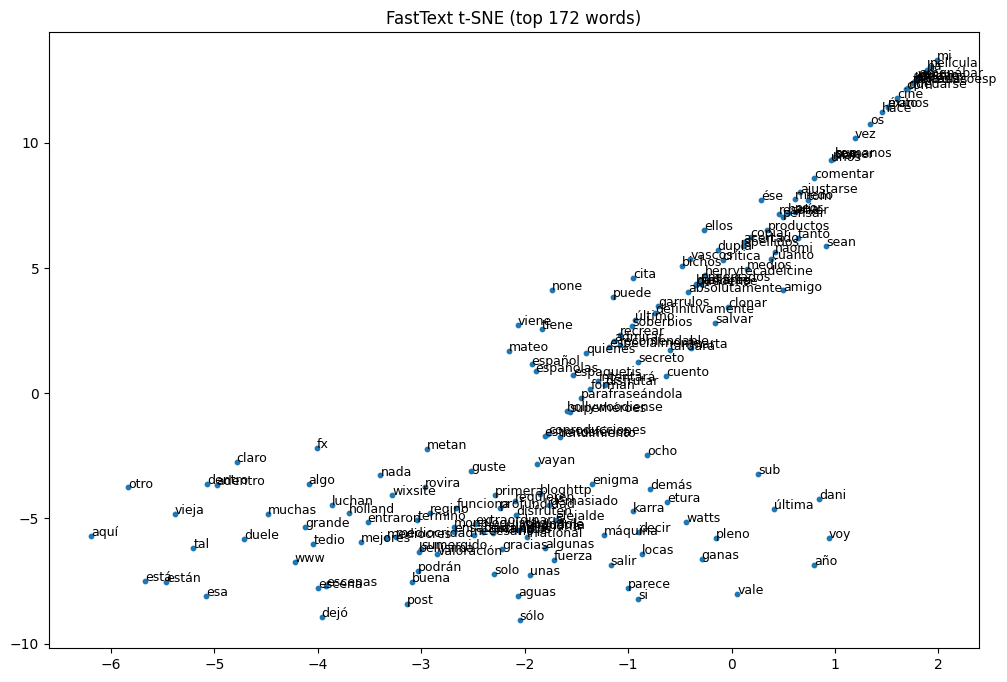

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

if len(ft_words) >= 2:
    ft_vectors_np = np.array(ft_vectors)

    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        max_iter=1000
    )
    coords = tsne.fit_transform(ft_vectors_np)

    plt.figure(figsize=(12, 8))
    plt.scatter(coords[:, 0], coords[:, 1], s=10)

    for i, w in enumerate(ft_words):
        plt.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=9)

    plt.title(f'FastText t-SNE (top {len(ft_words)} words)')
    plt.show()

else:
    print('No hay suficientes palabras para t-SNE en FastText')

In [66]:
w2v_vectors = [w2v_model.wv[w] for w in top_words if w in w2v_model.wv]
w2v_words = [w for w in top_words if w in w2v_model.wv]

In [67]:
if len(w2v_words) >= 2:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    coords = tsne.fit_transform(w2v_vectors)
    plt.figure(figsize=(12,8))
    plt.scatter(coords[:,0], coords[:,1], s=10)
    for i,w in enumerate(w2v_words):
        plt.annotate(w, (coords[i,0], coords[i,1]), fontsize=9)
    plt.title('Word2Vec t-SNE (top {} words)'.format(len(w2v_words)))
    plt.show()
else:
    print('No hay suficientes palabras para t-SNE en Word2Vec')

No hay suficientes palabras para t-SNE en Word2Vec


Añadimos algunos ejemplos

In [68]:
queries = ['amor','miedo','familia','acción','comedia','drama','terror','romance']
for q in queries:
    print('\nQuery:', q)
    try:
        print(' FastText:', ft_model.wv.most_similar(q, topn=10))
    except Exception as e:
        print(' FastText error/OOV:', e)
    try:
        print(' Word2Vec:', w2v_model.wv.most_similar(q, topn=10))
    except Exception as e:
        print(' Word2Vec error/OOV:', e)


Query: amor
 FastText: [('ver', 0.9222849011421204), ('cine', 0.922033965587616), ('ha', 0.9216317534446716), ('él', 0.9212332367897034), ('fantasticoesp', 0.9211056232452393), ('vez', 0.9209800958633423), ('película', 0.9205275774002075), ('quedarse', 0.9201993346214294), ('hacer', 0.9201858639717102), ('éxito', 0.9196787476539612)]
 Word2Vec error/OOV: "Key 'amor' not present in vocabulary"

Query: miedo
 FastText: [('mi', 0.9792574644088745), ('película', 0.978324830532074), ('créditos', 0.9782425165176392), ('mismo', 0.9781670570373535), ('com', 0.9780130386352539), ('quedarse', 0.9776898622512817), ('amenábar', 0.9776844382286072), ('fantasticoesp', 0.9776748418807983), ('hacer', 0.9775378704071045), ('manos', 0.9772334694862366)]
 Word2Vec error/OOV: "Key 'miedo' not present in vocabulary"

Query: familia
 FastText: [('él', 0.8754001259803772), ('mi', 0.8745245337486267), ('ha', 0.8731990456581116), ('créditos', 0.8730733394622803), ('fantasticoesp', 0.8721621036529541), ('hacer

Comparación solapa y Jaccard

In [69]:
from collections import Counter

def topk(simlist):
    if isinstance(simlist, list):
        return [w for w,_ in simlist]
    return []

for q in queries:
    print('\nQuery:', q)
    ft_top = []
    w2v_top = []
    try:
        ft_top = [w for w,_ in ft_model.wv.most_similar(q, topn=10)]
    except:
        pass
    try:
        w2v_top = [w for w,_ in w2v_model.wv.most_similar(q, topn=10)]
    except:
        pass
    overlap = set(ft_top) & set(w2v_top)
    union = set(ft_top) | set(w2v_top)
    jaccard = len(overlap)/len(union) if union else 0.0
    print('  FastText top:', ft_top)
    print('  Word2Vec top:', w2v_top)
    print('  Overlap:', overlap)
    print('  Jaccard:', jaccard)


Query: amor
  FastText top: ['ver', 'cine', 'ha', 'él', 'fantasticoesp', 'vez', 'película', 'quedarse', 'hacer', 'éxito']
  Word2Vec top: []
  Overlap: set()
  Jaccard: 0.0

Query: miedo
  FastText top: ['mi', 'película', 'créditos', 'mismo', 'com', 'quedarse', 'amenábar', 'fantasticoesp', 'hacer', 'manos']
  Word2Vec top: []
  Overlap: set()
  Jaccard: 0.0

Query: familia
  FastText top: ['él', 'mi', 'ha', 'créditos', 'fantasticoesp', 'hacer', 'com', 'mismo', 'película', 'manos']
  Word2Vec top: []
  Overlap: set()
  Jaccard: 0.0

Query: acción
  FastText top: ['none', 'recomendable', 'vez', 'él', 'ha', 'quedarse', 'mi', 'hacer', 'ver', 'película']
  Word2Vec top: []
  Overlap: set()
  Jaccard: 0.0

Query: comedia
  FastText top: ['com', 'mismo', 'película', 'ver', 'mi', 'amenábar', 'quedarse', 'hacer', 'fantasticoesp', 'manos']
  Word2Vec top: []
  Overlap: set()
  Jaccard: 0.0

Query: drama
  FastText top: ['none', 'vez', 'sea', 'éxito', 'cine', 'ha', 'película', 'quedarse', 'com',

In [70]:
out = '/colection/fasttext_word2vec_outputs'
os.makedirs(out, exist_ok=True)
ft_model.save(os.path.join(out, 'fasttext.model'))
w2v_model.save(os.path.join(out, 'word2vec.model'))
print('Saved models to', out)

Saved models to /colection/fasttext_word2vec_outputs


### 4.  Doc2Vect
* Construir un modelo Doc2Vect para el conjunto de datos en español
* Realizar comparaciones entre los documentos usando similitud (usar los mismos 5 documentos seleccionados en el punto 1)
* Revisar los documentos originales y analizar el resultado obtenido usando la similitud.

#### Lectura de datos

In [ ]:
import pandas as pd
import numpy as np
import re

df = pd.read_table('reviews_filmaffinity.csv', sep='\|\|', header=0, engine='python')
df.head()

<>:5: SyntaxWarning: invalid escape sequence '\|'
<>:5: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipython-input-1155715778.py:5: SyntaxWarning: invalid escape sequence '\|'
  df = pd.read_table('reviews_filmaffinity.csv', sep='\|\|', header=0, engine='python')


,film_name,gender,film_avg_rate,review_rate,review_title,review_text
0,Ocho apellidos vascos,Comedia,"6,0",3.0,OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO,La mayor virtud de esta película es su existen...
1,Ocho apellidos vascos,Comedia,"6,0",2.0,El perro verde,"No soy un experto cinéfilo, pero pocas veces m..."
2,Ocho apellidos vascos,Comedia,"6,0",2.0,Si no eres de comer mierda... no te comas esta...,Si no eres un incondicional del humor estilo T...
3,Ocho apellidos vascos,Comedia,"6,0",2.0,Aida: The movie,"No sé qué está pasando, si la gente se deja ll..."
4,Ocho apellidos vascos,Comedia,"6,0",2.0,UN HOMBRE SOLO (Julio Iglesias 1987),"""Pero cuando amanece,y me quedo solo,siento en..."


#### Tokenización

In [ ]:
import nltk

wpt = nltk.WordPunctTokenizer()
tokenized_corpus = [wpt.tokenize(row["review_text"]) for _, row in df.iterrows()]
display(tokenized_corpus[0])

['La',
 'mayor',
 'virtud',
 'de',
 'esta',
 'película',
 'es',
 'su',
 'existencia',
 '.',
 'El',
 'hecho',
 'de',
 'que',
 'podamos',
 'jugar',
 'con',
 'los',
 'tópicos',
 'más',
 'extremos',
 'de',
 'las',
 'identidades',
 'patrias',
 '(',
 'la',
 'andaluza',
 'y',
 'la',
 'vasca',
 ')',
 'sin',
 'que',
 'nadie',
 'se',
 'escandalice',
 'ni',
 'ponga',
 'el',
 'grito',
 'en',
 'el',
 'cielo',
 ',',
 'indica',
 'mucho',
 'de',
 'nuestra',
 'madurez',
 'como',
 'nación',
 '(',
 'pese',
 'a',
 'quien',
 'pese',
 ').',
 'Bueno',
 ',',
 'corrijo',
 ':',
 'el',
 'hecho',
 'de',
 'que',
 'podamos',
 'jugar',
 'y',
 'hacer',
 'mofa',
 'y',
 'befa',
 'de',
 'los',
 'tópicos',
 'sobre',
 'los',
 'vascos',
 'y',
 'el',
 'nacionalismo',
 'vasco',
 ',',
 'sin',
 'que',
 'nadie',
 'se',
 'escandalice',
 'ni',
 'ponga',
 'el',
 'grito',
 'en',
 'el',
 'cielo',
 ',',
 'indica',
 'mucho',
 'del',
 'grado',
 'de',
 'normalización',
 'de',
 'ciertas',
 'cuestiones',
 'que',
 'antes',
 'eran',
 'llaga

#### Construcción modelo Doc2Vect

In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 12.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requi

In [ ]:
from gensim.models.doc2vec import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from gensim.test.utils import common_texts

tagged_corpus = [
    TaggedDocument(doc, [i])
    for i, doc in enumerate(tokenized_corpus)
]

In [ ]:
display(tagged_corpus[0])

TaggedDocument(words=['La', 'mayor', 'virtud', 'de', 'esta', 'película', 'es', 'su', 'existencia', '.', 'El', 'hecho', 'de', 'que', 'podamos', 'jugar', 'con', 'los', 'tópicos', 'más', 'extremos', 'de', 'las', 'identidades', 'patrias', '(', 'la', 'andaluza', 'y', 'la', 'vasca', ')', 'sin', 'que', 'nadie', 'se', 'escandalice', 'ni', 'ponga', 'el', 'grito', 'en', 'el', 'cielo', ',', 'indica', 'mucho', 'de', 'nuestra', 'madurez', 'como', 'nación', '(', 'pese', 'a', 'quien', 'pese', ').', 'Bueno', ',', 'corrijo', ':', 'el', 'hecho', 'de', 'que', 'podamos', 'jugar', 'y', 'hacer', 'mofa', 'y', 'befa', 'de', 'los', 'tópicos', 'sobre', 'los', 'vascos', 'y', 'el', 'nacionalismo', 'vasco', ',', 'sin', 'que', 'nadie', 'se', 'escandalice', 'ni', 'ponga', 'el', 'grito', 'en', 'el', 'cielo', ',', 'indica', 'mucho', 'del', 'grado', 'de', 'normalización', 'de', 'ciertas', 'cuestiones', 'que', 'antes', 'eran', 'llagas', 'abiertas', 'siempre', 'dispuestas', 'a', 'sangrar', '.', 'Y', 'hago', 'esta', 'corr

In [ ]:
model = Doc2Vec(
    documents = tagged_corpus,
    vector_size = 50,
    epochs = 20,
    workers = -1 # específica que se debe usar el número máximo de procesos.
)

In [ ]:
vect = model.infer_vector(tagged_corpus[0].words)
display(vect)
display(vect.shape)

array([-0.00566679, -0.00325397, -0.00787004, -0.00311063,  0.00759652,
        0.00161121,  0.00905021, -0.00844624,  0.00313815,  0.00154176,
       -0.00370009, -0.00010512,  0.00489112, -0.0078833 , -0.00383814,
       -0.00224615, -0.00152403, -0.00762724,  0.0048543 , -0.00969164,
       -0.001008  , -0.00694963, -0.0095034 , -0.00350814, -0.00126001,
        0.00405642, -0.00360762,  0.00526332,  0.00448717, -0.0025269 ,
        0.00901732, -0.004231  ,  0.00871658,  0.00926286,  0.00647753,
       -0.00544857,  0.00669064, -0.00416014, -0.0062036 , -0.006275  ,
        0.00012138,  0.00683474,  0.00701983, -0.00437331, -0.0044872 ,
        0.00146544,  0.00849708, -0.00360305,  0.00987724, -0.00357599],
      dtype=float32)

(50,)

#### Cómputo de similitudes

In [ ]:
from scipy import spatial

cosine_similarity = lambda x, y: 1 - spatial.distance.cosine(x, y)

# Compute similarity between the selected documents
similarity_matrix = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        similarity_matrix[i, j] = cosine_similarity(model.infer_vector(tagged_corpus[i].words), model.infer_vector(tagged_corpus[j].words))

display(similarity_matrix)


array([[ 1.        ,  0.01960327,  0.02165799, -0.07255421, -0.1686725 ],
       [ 0.01960327,  1.        ,  0.13354976, -0.14562766, -0.01063822],
       [ 0.02165799,  0.13354976,  0.99999999, -0.03520983, -0.16968811],
       [-0.07255421, -0.14562766, -0.03520983,  1.        ,  0.16278675],
       [-0.1686725 , -0.01063822, -0.16968811,  0.16278675,  1.        ]])

#### Análisis de resultados

##### Información de los documentos

In [ ]:
for i in range(5):
    print(df.iloc[i])

film_name                                    Ocho apellidos vascos
gender                                                     Comedia
film_avg_rate                                                  6,0
review_rate                                                    3.0
review_title        OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO
review_text      La mayor virtud de esta película es su existen...
Name: 0, dtype: object
film_name                                    Ocho apellidos vascos
gender                                                     Comedia
film_avg_rate                                                  6,0
review_rate                                                    2.0
review_title                                        El perro verde
review_text      No soy un experto cinéfilo, pero pocas veces m...
Name: 1, dtype: object
film_name                                    Ocho apellidos vascos
gender                                                     Comedia
film_avg_rate   

#### Textos originales

In [ ]:
print(df.iloc[0]["review_text"] + '\n')
print(df.iloc[1]["review_text"] + '\n')
print(df.iloc[2]["review_text"] + '\n')
print(df.iloc[3]["review_text"] + '\n')
print(df.iloc[4]["review_text"] + '\n')

La mayor virtud de esta película es su existencia.El hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y la vasca) sin que nadie se escandalice ni ponga el grito en el cielo, indica mucho de nuestra madurez como nación (pese a quien pese). Bueno, corrijo: el hecho de que podamos jugar y hacer mofa y befa de los tópicos sobre los vascos y el nacionalismo vasco, sin que nadie se escandalice ni ponga el grito en el cielo, indica mucho del grado de normalización de ciertas cuestiones que antes eran llagas abiertas siempre dispuestas a sangrar. Y hago esta corrección, porque los andaluces han sido motivo de guasa siempre y nunca ha pasado nada.Por esto mismo, el planteamiento de "Ocho Apellidos Vascos" es valiente, es oportuno y es oportunista. Seguramente sea esa una de las principales razones por la que los españoles hemos acudido en masa, en una masa casi sin precedentes, a los cines a ver este producto patrocinado por Tele 5. Esa junto con l

##### Análisis
Aunque todas las reseñas analizadas corresponden a **Ocho apellidos vascos** y comparten una valoración negativa, el modelo Doc2Vec muestra diferencias claras en estilo y contenido.

* Los documentos 2 y 3 presentan la mayor similitud (0.13), ya que ambas son críticas coloquiales y directas, con un tono de frustración.
* Los documentos 4 y 5 son los más similares (0.16), pues comparten un estilo breve e irónico con referencias externas.
* El documento 1 se comporta como un outlier: es una reseña extensa y reflexiva, muy diferente al resto, especialmente frente al documento 5 (-0.17), que es corto y paródico.

En general, las similitudes son bajas, lo que refleja que, pese a referirse a la misma película y coincidir en la valoración negativa, los autores adoptan tonos y estilos muy distintos.